# Le LSTM Pas à Pas
## Comprendre le Long Short-Term Memory avec PyTorch

Dans ce notebook, nous allons construire un LSTM de zéro, en implémentant chaque porte manuellement.  
L'objectif est de comprendre **ce qui se passe vraiment** à l'intérieur d'une couche LSTM.

---
## Setup & Imports

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.titlesize'] = 11

torch.manual_seed(42)

PyTorch version : 2.10.0


---
## Pourquoi le LSTM ?

Un RNN classique souffre du **problème du gradient qui disparaît** : pour des séquences longues,
le réseau oublie rapidement ce qui s'est passé au début.  

Le **LSTM** résout ce problème grâce à une **cellule mémoire** `c_t` et **trois portes** qui contrôlent
ce qu'on garde, ce qu'on oublie et ce qu'on transmet.

```
Séquence :   x₁ → x₂ → x₃ → ... → xₜ
                                      ↓
             ┌──────────────────────────────┐
             │  Porte oubli  (forget gate)  │  ← Qu'est-ce qu'on efface ?
             │  Porte entrée (input gate)   │  ← Qu'est-ce qu'on mémorise ?
             │  Porte sortie (output gate)  │  ← Qu'est-ce qu'on expose ?
             └──────────────────────────────┘
                    ↓              ↓
             c_t (mémoire)   a_t (état caché)
```

---
## L'opération fondamentale : la porte

Avant de parler de LSTM complet, posons la brique de base : **une porte**.  

Une porte est simplement une **multiplication élément par élément** entre un vecteur
d'information et un vecteur de valeurs entre 0 et 1 (la "clé" de la porte) :

- **0** → l'information est bloquée (oubliée)
- **1** → l'information passe intégralement
- Entre les deux → passage partiel

In [2]:
# Information à filtrer (ex : état mémoire)
memoire = torch.tensor([0.8, -0.5, 0.3, 0.9, -0.2])

# Clé de la porte (valeurs entre 0 et 1)
porte = torch.tensor([1.0, 0.0, 0.5, 0.0, 1.0])

# L'opération fondamentale d'une porte
resultat = memoire * porte

print("Mémoire :          ", memoire.numpy())
print("Porte (0=bloquer) :", porte.numpy())
print("Résultat :         ", resultat.numpy())
print()
print("→ Position 0 (porte=1.0) : information passée intacte")
print("→ Position 1 (porte=0.0) : information bloquée")
print("→ Position 2 (porte=0.5) : information à moitié")

Mémoire :           [ 0.8 -0.5  0.3  0.9 -0.2]
Porte (0=bloquer) : [1.  0.  0.5 0.  1. ]
Résultat :          [ 0.8  -0.    0.15  0.   -0.2 ]

→ Position 0 (porte=1.0) : information passée intacte
→ Position 1 (porte=0.0) : information bloquée
→ Position 2 (porte=0.5) : information à moitié


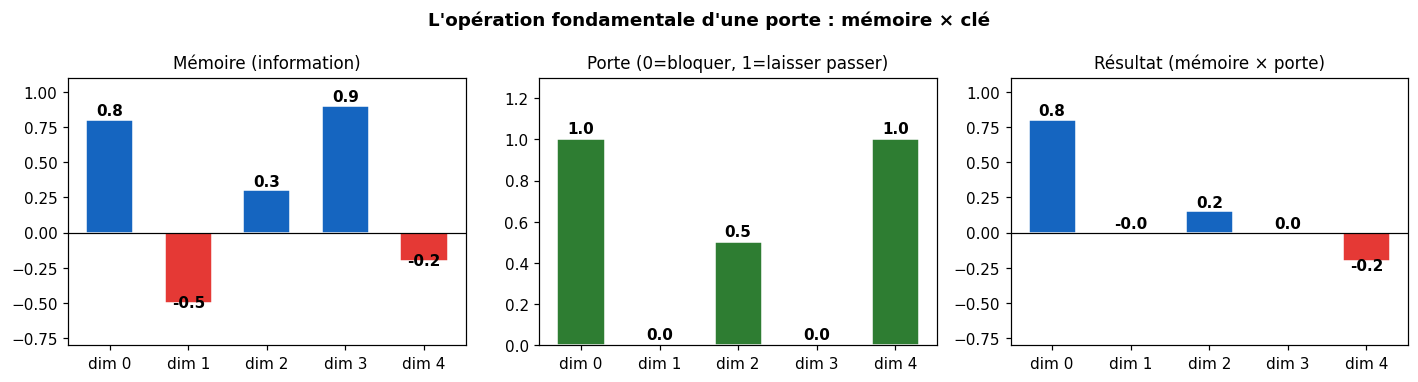

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

labels = [f"dim {i}" for i in range(5)]
x = np.arange(5)
largeur = 0.6

colors_mem  = ['#1565C0' if v > 0 else '#e53935' for v in memoire.numpy()]
colors_port = ['#2E7D32' for _ in range(5)]
colors_res  = ['#1565C0' if v > 0 else '#e53935' for v in resultat.numpy()]

# Mémoire
axes[0].bar(x, memoire.numpy(), color=colors_mem, width=largeur, edgecolor='white')
for i, v in enumerate(memoire.numpy()):
    axes[0].text(i, v + 0.03 * np.sign(v), f"{v:.1f}", ha='center', fontsize=10, fontweight='bold')
axes[0].set_title("Mémoire (information)"); axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
axes[0].axhline(0, color='black', linewidth=0.8); axes[0].set_ylim(-0.8, 1.1)

# Porte
axes[1].bar(x, porte.numpy(), color=colors_port, width=largeur, edgecolor='white')
for i, v in enumerate(porte.numpy()):
    axes[1].text(i, v + 0.03, f"{v:.1f}", ha='center', fontsize=10, fontweight='bold')
axes[1].set_title("Porte (0=bloquer, 1=laisser passer)"); axes[1].set_xticks(x); axes[1].set_xticklabels(labels)
axes[1].set_ylim(0, 1.3)

# Résultat
axes[2].bar(x, resultat.numpy(), color=colors_res, width=largeur, edgecolor='white')
for i, v in enumerate(resultat.numpy()):
    offset = 0.03 if v >= 0 else -0.07
    axes[2].text(i, v + offset, f"{v:.1f}", ha='center', fontsize=10, fontweight='bold')
axes[2].set_title("Résultat (mémoire × porte)"); axes[2].set_xticks(x); axes[2].set_xticklabels(labels)
axes[2].axhline(0, color='black', linewidth=0.8); axes[2].set_ylim(-0.8, 1.1)

fig.suptitle("L'opération fondamentale d'une porte : mémoire × clé", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Les équations du LSTM

À chaque pas de temps `t`, le LSTM reçoit l'entrée `x_t` et l'état caché précédent `a_{t-1}`.  
Il calcule **4 vecteurs intermédiaires** puis met à jour la mémoire et l'état caché :

```
Entrées combinées :  z = [a_{t-1}, x_t]   (concaténation)

Porte oubli  :  f_t = σ(W_f · z + b_f)    ← Que garder de la mémoire passée ?
Porte entrée :  i_t = σ(W_i · z + b_i)    ← Quelle nouvelle info mémoriser ?
Candidat     :  g_t = tanh(W_g · z + b_g) ← Quelle nouvelle info proposer ?
Porte sortie :  o_t = σ(W_o · z + b_o)    ← Que révéler à la sortie ?

Mise à jour mémoire  :  c_t = f_t ⊙ c_{t-1}  +  i_t ⊙ g_t
Nouvel état caché    :  a_t = o_t ⊙ tanh(c_t)
```

**σ** = sigmoid (sortie entre 0 et 1, idéale pour les portes)  
**tanh** (sortie entre -1 et 1, idéale pour les valeurs de mémoire)  
**⊙** = multiplication élément par élément (comme vu ci-dessus)

---
## Les fonctions d'activation : sigmoid et tanh

Avant d'implémenter le LSTM, visualisons les deux fonctions d'activation utilisées.

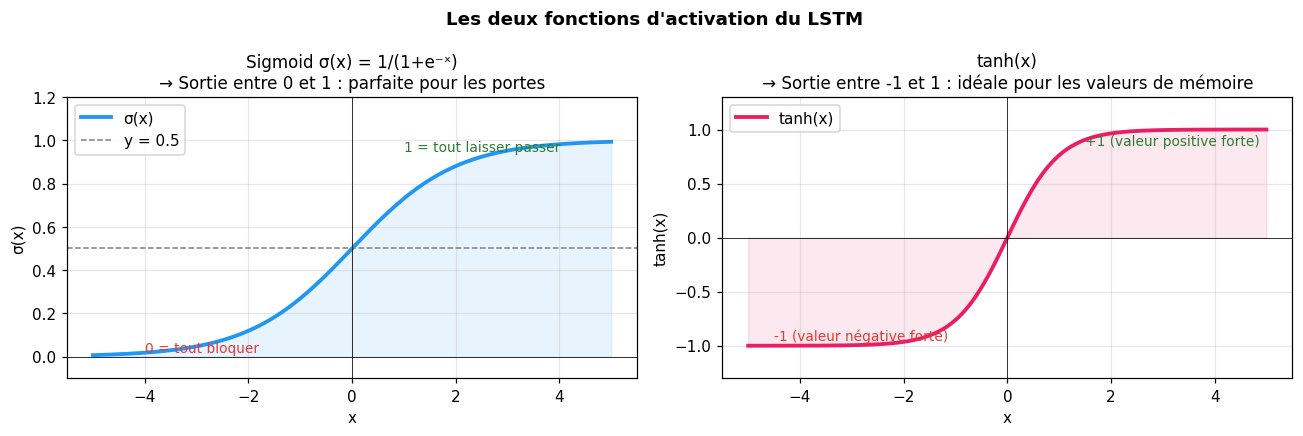

In [4]:
x_vals = torch.linspace(-5, 5, 200)

sigmoid_vals = torch.sigmoid(x_vals)
tanh_vals    = torch.tanh(x_vals)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Sigmoid
axes[0].plot(x_vals.numpy(), sigmoid_vals.numpy(), color='#2196F3', linewidth=2.5, label='σ(x)')
axes[0].axhline(0.5, color='gray', linestyle='--', linewidth=1, label='y = 0.5')
axes[0].axhline(0,   color='black', linewidth=0.5)
axes[0].axvline(0,   color='black', linewidth=0.5)
axes[0].fill_between(x_vals.numpy(), 0, sigmoid_vals.numpy(), alpha=0.1, color='#2196F3')
axes[0].set_ylim(-0.1, 1.2)
axes[0].set_title("Sigmoid σ(x) = 1/(1+e⁻ˣ)\n→ Sortie entre 0 et 1 : parfaite pour les portes")
axes[0].set_xlabel("x"); axes[0].set_ylabel("σ(x)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].annotate("0 = tout bloquer",  xy=(-4, 0.02), fontsize=9, color='#e53935')
axes[0].annotate("1 = tout laisser passer", xy=(1, 0.95), fontsize=9, color='#2E7D32')

# Tanh
axes[1].plot(x_vals.numpy(), tanh_vals.numpy(), color='#E91E63', linewidth=2.5, label='tanh(x)')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].axvline(0, color='black', linewidth=0.5)
axes[1].fill_between(x_vals.numpy(), 0, tanh_vals.numpy(), alpha=0.1, color='#E91E63')
axes[1].set_ylim(-1.3, 1.3)
axes[1].set_title("tanh(x)\n→ Sortie entre -1 et 1 : idéale pour les valeurs de mémoire")
axes[1].set_xlabel("x"); axes[1].set_ylabel("tanh(x)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].annotate("-1 (valeur négative forte)", xy=(-4.5, -0.95), fontsize=9, color='#e53935')
axes[1].annotate("+1 (valeur positive forte)", xy=(1.5,   0.85), fontsize=9, color='#2E7D32')

fig.suptitle("Les deux fonctions d'activation du LSTM", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Implémentation manuelle d'un pas LSTM

Implémentons maintenant **un seul pas de temps** du LSTM à la main, porte par porte.

In [5]:
# Dimensions
input_size  = 3   # taille de l'entrée x_t
hidden_size = 4   # taille de l'état caché a_t

# Initialisation des poids (pour une cellule, chaque porte a W et b)
torch.manual_seed(0)

# Poids des 4 portes : input → hidden et hidden → hidden
W_f = torch.randn(hidden_size, input_size + hidden_size) * 0.1   # forget gate
b_f = torch.zeros(hidden_size)

W_i = torch.randn(hidden_size, input_size + hidden_size) * 0.1   # input gate
b_i = torch.zeros(hidden_size)

W_g = torch.randn(hidden_size, input_size + hidden_size) * 0.1   # candidat
b_g = torch.zeros(hidden_size)

W_o = torch.randn(hidden_size, input_size + hidden_size) * 0.1   # output gate
b_o = torch.zeros(hidden_size)

print(f"Taille des poids W : {W_f.shape}  (hidden_size × (input + hidden))")
print(f"Taille des biais  b : {b_f.shape}  (hidden_size)")

Taille des poids W : torch.Size([4, 7])  (hidden_size × (input + hidden))
Taille des biais  b : torch.Size([4])  (hidden_size)


In [6]:
def lstm_step_manuel(x_t, a_prev, c_prev, W_f, b_f, W_i, b_i, W_g, b_g, W_o, b_o):
    """
    Un seul pas de temps d'un LSTM — implémentation manuelle porte par porte.

    x_t    : (input_size,)   — entrée au temps t
    a_prev : (hidden_size,)  — état caché précédent
    c_prev : (hidden_size,)  — mémoire de cellule précédente

    Retourne : a_t, c_t, et un dictionnaire de debug (valeurs intermédiaires)
    """
    # ① Concaténer l'entrée et l'état caché
    z = torch.cat([a_prev, x_t])     # (input_size + hidden_size,)

    # ② Calculer les 4 portes
    f_t = torch.sigmoid(W_f @ z + b_f)    # porte oubli   → [0,1]
    i_t = torch.sigmoid(W_i @ z + b_i)    # porte entrée  → [0,1]
    g_t = torch.tanh   (W_g @ z + b_g)    # candidat      → [-1,1]
    o_t = torch.sigmoid(W_o @ z + b_o)    # porte sortie  → [0,1]

    # ③ Mettre à jour la mémoire de cellule
    c_t = f_t * c_prev  +  i_t * g_t      # ⊙ = multiplication élément par élément

    # ④ Calculer le nouvel état caché
    a_t = o_t * torch.tanh(c_t)

    debug = {'z': z, 'f_t': f_t, 'i_t': i_t, 'g_t': g_t, 'o_t': o_t,
             'c_prev': c_prev, 'c_t': c_t, 'a_t': a_t}
    return a_t, c_t, debug


# Test sur un vecteur d'entrée simple
x_t    = torch.tensor([1.0, 0.5, -0.3])   # entrée au temps t
a_prev = torch.zeros(hidden_size)           # état caché initial
c_prev = torch.zeros(hidden_size)           # mémoire initiale

a_t, c_t, debug = lstm_step_manuel(x_t, a_prev, c_prev, W_f, b_f, W_i, b_i, W_g, b_g, W_o, b_o)

print("=== Résultats pour un pas de temps ===")
print(f"Entrée x_t      : {x_t.numpy()}")
print()
print(f"Porte oubli  f_t : {debug['f_t'].detach().numpy().round(3)}  (entre 0 et 1)")
print(f"Porte entrée i_t : {debug['i_t'].detach().numpy().round(3)}  (entre 0 et 1)")
print(f"Candidat     g_t : {debug['g_t'].detach().numpy().round(3)}  (entre -1 et 1)")
print(f"Porte sortie o_t : {debug['o_t'].detach().numpy().round(3)}  (entre 0 et 1)")
print()
print(f"Mémoire c_t : {c_t.detach().numpy().round(3)}")
print(f"État caché a_t : {a_t.detach().numpy().round(3)}")

=== Résultats pour un pas de temps ===
Entrée x_t      : [ 1.   0.5 -0.3]

Porte oubli  f_t : [0.532 0.503 0.486 0.516]  (entre 0 et 1)
Porte entrée i_t : [0.486 0.546 0.469 0.508]  (entre 0 et 1)
Candidat     g_t : [ 0.23   0.197 -0.127  0.12 ]  (entre -1 et 1)
Porte sortie o_t : [0.522 0.526 0.524 0.487]  (entre 0 et 1)

Mémoire c_t : [ 0.112  0.108 -0.06   0.061]
État caché h_t : [ 0.058  0.056 -0.031  0.03 ]


---
## Implémentation sur une séquence complète

Maintenant, appliquons notre LSTM sur **plusieurs pas de temps** pour traiter une séquence entière.

In [8]:
def lstm_sequence_manuel(sequence, hidden_size, W_f, b_f, W_i, b_i, W_g, b_g, W_o, b_o):
    """
    Applique le LSTM sur une séquence entière.

    sequence : (T, input_size)  — T pas de temps
    Retourne : a_all (T, hidden_size) — tous les états cachés
    """
    T = sequence.shape[0]
    a_prev = torch.zeros(hidden_size)
    c_prev = torch.zeros(hidden_size)

    a_all     = []
    c_all     = []
    debug_all = []

    for t in range(T):
        x_t = sequence[t]
        a_t, c_t, debug = lstm_step_manuel(x_t, a_prev, c_prev,
                                             W_f, b_f, W_i, b_i, W_g, b_g, W_o, b_o)
        a_all.append(a_t.detach())
        c_all.append(c_t.detach())
        debug_all.append(debug)
        a_prev = a_t
        c_prev = c_t

    return torch.stack(a_all), torch.stack(c_all), debug_all


# Séquence de test : 8 pas de temps, input_size=3
T = 8
torch.manual_seed(1)
sequence = torch.randn(T, input_size)

a_all, c_all, debug_all = lstm_sequence_manuel(sequence, hidden_size, W_f, b_f, W_i, b_i, W_g, b_g, W_o, b_o)

print(f"Séquence en entrée  : {sequence.shape}  ({T} pas × {input_size} features)")
print(f"États cachés a_all  : {a_all.shape}    ({T} pas × {hidden_size} hidden)")
print(f"Mémoires     c_all  : {c_all.shape}    ({T} pas × {hidden_size} hidden)")

Séquence en entrée  : torch.Size([8, 3])  (8 pas × 3 features)
États cachés h_all  : torch.Size([8, 4])    (8 pas × 4 hidden)
Mémoires     c_all  : torch.Size([8, 4])    (8 pas × 4 hidden)


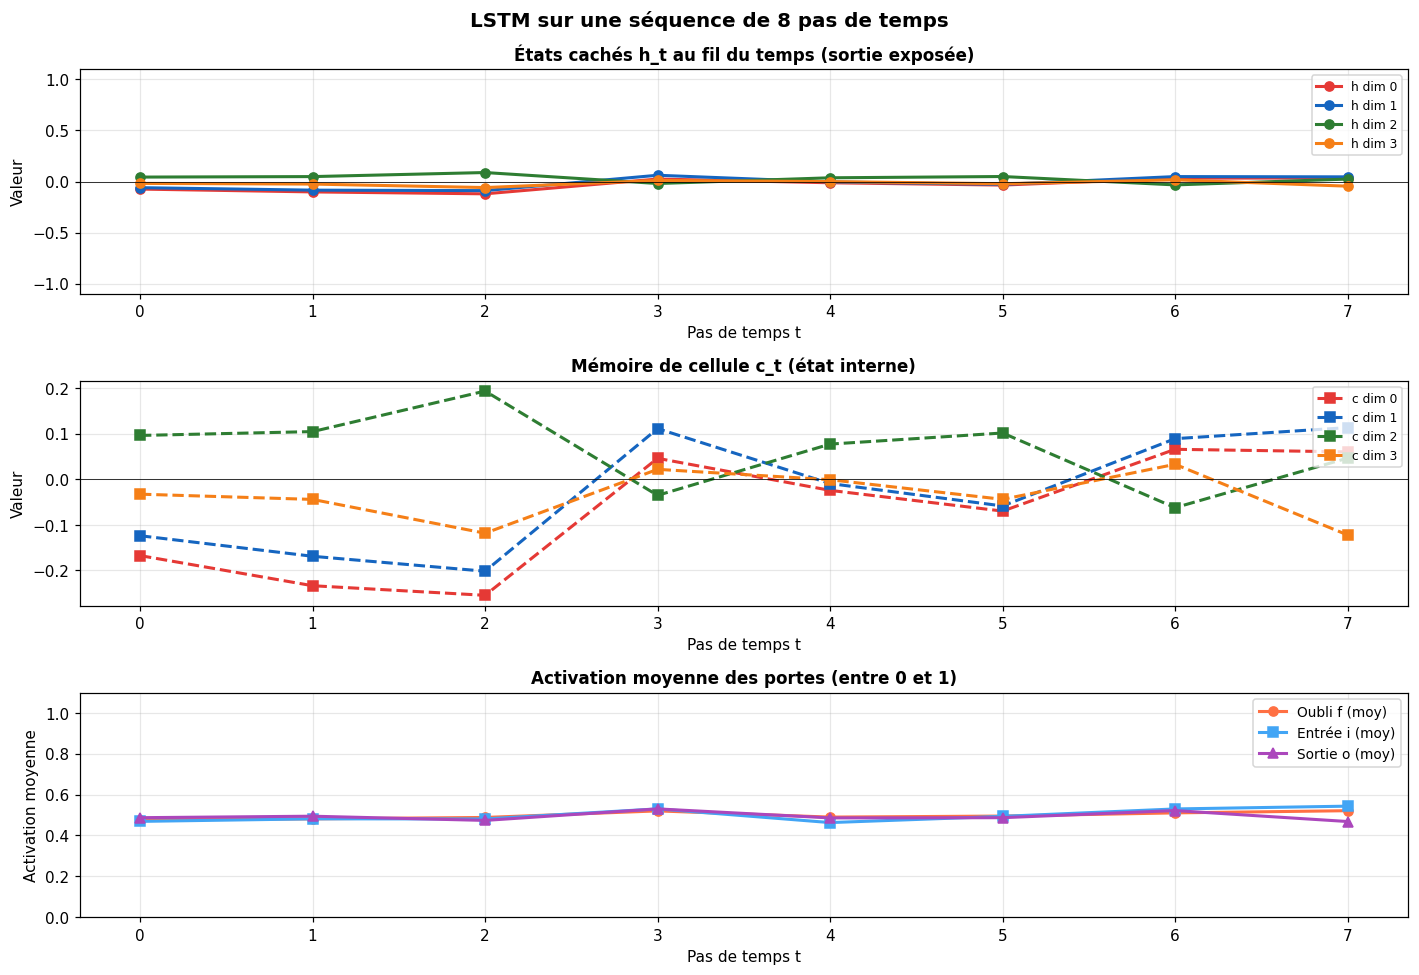

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9))

temps = np.arange(T)
couleurs = ['#e53935', '#1565C0', '#2E7D32', '#F57F17']

# État caché a_t
for d in range(hidden_size):
    axes[0].plot(temps, a_all[:, d].numpy(), 'o-', color=couleurs[d],
                 linewidth=2, markersize=6, label=f"a dim {d}")
axes[0].set_title("États cachés a_t au fil du temps (sortie exposée)", fontweight='bold')
axes[0].set_xlabel("Pas de temps t"); axes[0].set_ylabel("Valeur")
axes[0].legend(loc='upper right', fontsize=8); axes[0].grid(True, alpha=0.3)
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_ylim(-1.1, 1.1)

# Mémoire de cellule c_t
for d in range(hidden_size):
    axes[1].plot(temps, c_all[:, d].numpy(), 's--', color=couleurs[d],
                 linewidth=2, markersize=6, label=f"c dim {d}")
axes[1].set_title("Mémoire de cellule c_t (état interne)", fontweight='bold')
axes[1].set_xlabel("Pas de temps t"); axes[1].set_ylabel("Valeur")
axes[1].legend(loc='upper right', fontsize=8); axes[1].grid(True, alpha=0.3)
axes[1].axhline(0, color='black', linewidth=0.5)

# Valeurs des portes (moyennées sur les dimensions pour simplifier)
f_means = [debug['f_t'].mean().item() for debug in debug_all]
i_means = [debug['i_t'].mean().item() for debug in debug_all]
o_means = [debug['o_t'].mean().item() for debug in debug_all]

axes[2].plot(temps, f_means, 'o-', color='#FF7043', linewidth=2, markersize=6, label='Oubli f (moy)')
axes[2].plot(temps, i_means, 's-', color='#42A5F5', linewidth=2, markersize=6, label='Entrée i (moy)')
axes[2].plot(temps, o_means, '^-', color='#AB47BC', linewidth=2, markersize=6, label='Sortie o (moy)')
axes[2].set_title("Activation moyenne des portes (entre 0 et 1)", fontweight='bold')
axes[2].set_xlabel("Pas de temps t"); axes[2].set_ylabel("Activation moyenne")
axes[2].legend(fontsize=9); axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(0, 1.1)

fig.suptitle("LSTM sur une séquence de 8 pas de temps", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Utiliser `nn.LSTM` dans un vrai modèle

Maintenant qu'on comprend ce qui se passe à l'intérieur, voyons comment **utiliser `nn.LSTM` correctement**.

In [11]:
# ── Architecture d'un modèle LSTM simple ─────────────────────────────────────

class ModeleLSTM(nn.Module):
    """
    LSTM simple pour régression sur une séquence.
    Entrée  : (batch, T, input_size)
    Sortie  : (batch, output_size)  — prédiction sur le dernier pas de temps
    """
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.lstm   = nn.LSTM(input_size, hidden_size, num_layers=num_layers,
                              batch_first=True)   # batch_first=True : (batch, T, features)
        self.sortie = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x : (batch, T, input_size)

        # nn.LSTM retourne :
        #   output  : (batch, T, hidden_size) — tous les états cachés
        #   (a_n, c_n) : états final (num_layers, batch, hidden_size)
        output, (a_n, c_n) = self.lstm(x)

        # On utilise uniquement le dernier état caché
        dernier_a = output[:, -1, :]    # (batch, hidden_size)

        # Couche linéaire finale
        return self.sortie(dernier_a)   # (batch, output_size)


# Test d'instantiation
modele = ModeleLSTM(input_size=5, hidden_size=32, output_size=1)
print(modele)
print()

# Test avec un batch de 4 séquences de longueur 10
batch = torch.randn(4, 10, 5)
sortie = modele(batch)
print(f"Entrée  : {batch.shape}   (batch=4, T=10, features=5)")
print(f"Sortie  : {sortie.shape}  (batch=4, output=1)")

ModeleLSTM(
  (lstm): LSTM(5, 32, batch_first=True)
  (sortie): Linear(in_features=32, out_features=1, bias=True)
)

Entrée  : torch.Size([4, 10, 5])   (batch=4, T=10, features=5)
Sortie  : torch.Size([4, 1])  (batch=4, output=1)


---
## Application : prédire une sinusoïde

Entraînons le LSTM sur une tâche concrète :  
**prédire le prochain point d'une sinusoïde** à partir des 20 points précédents.

Train : torch.Size([464, 20, 1])  |  Test : torch.Size([116, 20, 1])


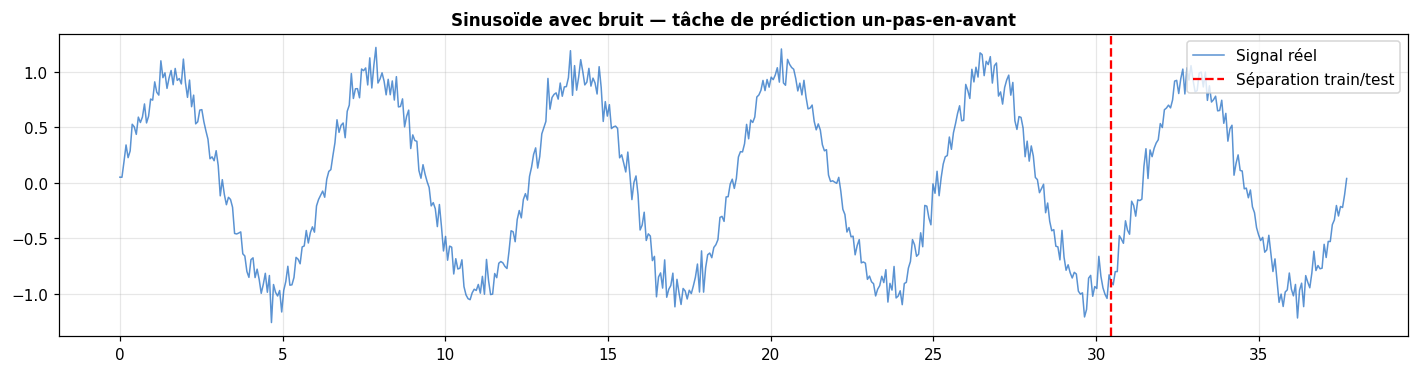

In [12]:
# ── Génération des données ────────────────────────────────────────────────────

np.random.seed(42)
N       = 600         # nombre total de points
T_entree = 20         # longueur de la fenêtre d'entrée

t    = np.linspace(0, 12 * np.pi, N)
data = np.sin(t) + 0.1 * np.random.randn(N)   # sinusoïde + bruit

# Normalisation
data_mean, data_std = data.mean(), data.std()
data_norm = (data - data_mean) / data_std

# Construire X (séquences) et y (valeur suivante)
X = np.array([data_norm[i : i + T_entree]     for i in range(N - T_entree)])
y = np.array([data_norm[i + T_entree]         for i in range(N - T_entree)])

# Conversion en tenseurs, ajout dim features
X_t = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)   # (N-T, T, 1)
y_t = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)   # (N-T, 1)

# Split train/test (80/20)
split  = int(0.8 * len(X_t))
X_train, X_test = X_t[:split], X_t[split:]
y_train, y_test = y_t[:split], y_t[split:]

print(f"Train : {X_train.shape}  |  Test : {X_test.shape}")

# Visualisation
fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(t, data, color='#1565C0', linewidth=1, alpha=0.7, label='Signal réel')
ax.axvline(t[split + T_entree], color='red', linestyle='--', linewidth=1.5, label='Séparation train/test')
ax.set_title("Sinusoïde avec bruit — tâche de prédiction un-pas-en-avant", fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# ── Entraînement ──────────────────────────────────────────────────────────────

torch.manual_seed(42)

modele_sin = ModeleLSTM(input_size=1, hidden_size=32, output_size=1)
optimiseur = torch.optim.Adam(modele_sin.parameters(), lr=1e-3)
critere    = nn.MSELoss()

EPOCHS      = 50
BATCH_SIZE  = 64
pertes_train = []

for epoch in range(EPOCHS):
    modele_sin.train()
    perte_epoch = 0.0
    n_batches   = 0

    # Mini-batches
    for debut in range(0, len(X_train), BATCH_SIZE):
        fin   = min(debut + BATCH_SIZE, len(X_train))
        xb    = X_train[debut:fin]
        yb    = y_train[debut:fin]

        optimiseur.zero_grad()
        pred  = modele_sin(xb)
        perte = critere(pred, yb)
        perte.backward()
        optimiseur.step()

        perte_epoch += perte.item()
        n_batches   += 1

    pertes_train.append(perte_epoch / n_batches)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS}  —  Perte train : {pertes_train[-1]:.5f}")

print("\nEntraînement terminé !")

Epoch  10/50  —  Perte train : 0.13983
Epoch  20/50  —  Perte train : 0.03204
Epoch  30/50  —  Perte train : 0.02611
Epoch  40/50  —  Perte train : 0.02570
Epoch  50/50  —  Perte train : 0.02545

Entraînement terminé !


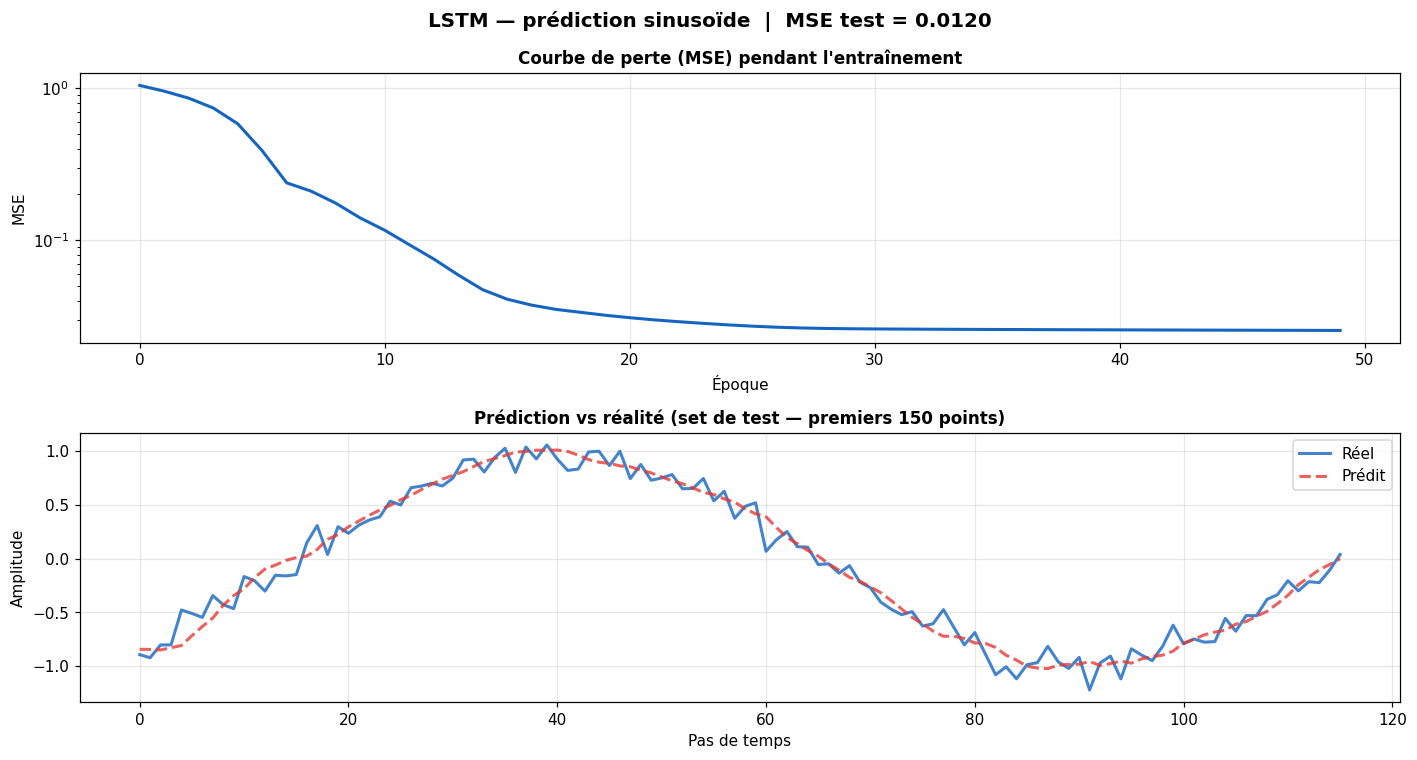

In [14]:
# ── Visualisation des résultats ───────────────────────────────────────────────

modele_sin.eval()
with torch.no_grad():
    pred_test = modele_sin(X_test).squeeze().numpy()

y_test_np = y_test.squeeze().numpy()

# Dénormaliser pour afficher en valeurs originales
pred_orig = pred_test * data_std + data_mean
vrai_orig = y_test_np * data_std + data_mean

fig, axes = plt.subplots(2, 1, figsize=(13, 7))

# Courbe de perte
axes[0].plot(pertes_train, color='#1565C0', linewidth=2)
axes[0].set_title("Courbe de perte (MSE) pendant l'entraînement", fontweight='bold')
axes[0].set_xlabel("Époque"); axes[0].set_ylabel("MSE")
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# Prédictions vs réalité
n_show = min(150, len(pred_orig))
axes[1].plot(vrai_orig[:n_show], color='#1565C0', linewidth=2, label='Réel', alpha=0.8)
axes[1].plot(pred_orig[:n_show], color='#e53935', linewidth=2, linestyle='--',
             label='Prédit', alpha=0.8)
axes[1].set_title("Prédiction vs réalité (set de test — premiers 150 points)", fontweight='bold')
axes[1].set_xlabel("Pas de temps"); axes[1].set_ylabel("Amplitude")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

mse_test = ((pred_orig - vrai_orig)**2).mean()
fig.suptitle(f"LSTM — prédiction sinusoïde  |  MSE test = {mse_test:.4f}",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Paramètres importants de `nn.LSTM`

Récapitulons les paramètres clés à connaître quand on utilise `nn.LSTM` en PyTorch.

In [15]:
# ── Démonstration des paramètres principaux ───────────────────────────────────

print("=" * 55)
print("  Paramètres de nn.LSTM")
print("=" * 55)

parametres = [
    ("input_size",   "5",          "Taille du vecteur d'entrée à chaque pas"),
    ("hidden_size",  "64",         "Taille de l'état caché a_t (= capacité mémoire)"),
    ("num_layers",   "2",          "Nombre de couches LSTM empilées (LSTM profond)"),
    ("batch_first",  "True",       "Forme (batch, T, features) si True, sinon (T, batch, features)"),
    ("dropout",      "0.2",        "Dropout entre les couches (num_layers > 1 requis)"),
    ("bidirectional","True",       "LSTM bidirectionnel : lit la séquence dans les 2 sens"),
]

for nom, val, desc in parametres:
    print(f"  {nom:<15} = {val:<8}  # {desc}")

print()
print("=" * 55)
print("  Sorties de nn.LSTM")
print("=" * 55)

sorties = [
    ("output",   "(batch, T, hidden*D)",            "Tous les états cachés (D=2 si bidirectionnel)"),
    ("a_n",      "(layers*D, batch, hidden)",       "État caché final"),
    ("c_n",      "(layers*D, batch, hidden)",       "Mémoire de cellule finale"),
]

for nom, forme, desc in sorties:
    print(f"  {nom:<8}  {forme:<32}  # {desc}")

print()

# Exemple concret avec LSTM à 2 couches
lstm_2couches = nn.LSTM(input_size=5, hidden_size=64, num_layers=2,
                         batch_first=True, dropout=0.2)
x_exemple = torch.randn(8, 20, 5)   # batch=8, T=20, features=5

with torch.no_grad():
    out, (a_n, c_n) = lstm_2couches(x_exemple)

print("Exemple avec 2 couches LSTM :")
print(f"  Entrée          : {x_exemple.shape}  (batch=8, T=20, features=5)")
print(f"  output          : {out.shape}        (batch=8, T=20, hidden=64)")
print(f"  a_n             : {a_n.shape}        (layers=2, batch=8, hidden=64)")
print(f"  c_n             : {c_n.shape}        (layers=2, batch=8, hidden=64)")

  Paramètres de nn.LSTM
  input_size      = 5         # Taille du vecteur d'entrée à chaque pas
  hidden_size     = 64        # Taille de l'état caché h_t (= capacité mémoire)
  num_layers      = 2         # Nombre de couches LSTM empilées (LSTM profond)
  batch_first     = True      # Forme (batch, T, features) si True, sinon (T, batch, features)
  dropout         = 0.2       # Dropout entre les couches (num_layers > 1 requis)
  bidirectional   = True      # LSTM bidirectionnel : lit la séquence dans les 2 sens

  Sorties de nn.LSTM
  output    (batch, T, hidden*D)              # Tous les états cachés (D=2 si bidirectionnel)
  h_n       (layers*D, batch, hidden)         # État caché final
  c_n       (layers*D, batch, hidden)         # Mémoire de cellule finale

Exemple avec 2 couches LSTM :
  Entrée          : torch.Size([8, 20, 5])  (batch=8, T=20, features=5)
  output          : torch.Size([8, 20, 64])        (batch=8, T=20, hidden=64)
  h_n             : torch.Size([2, 8, 64])    

---
## Visualisation de l'effet du `hidden_size`

Le `hidden_size` détermine la **capacité mémoire** du LSTM.  
Plus il est grand, plus le réseau peut mémoriser d'informations, mais plus il a de paramètres.

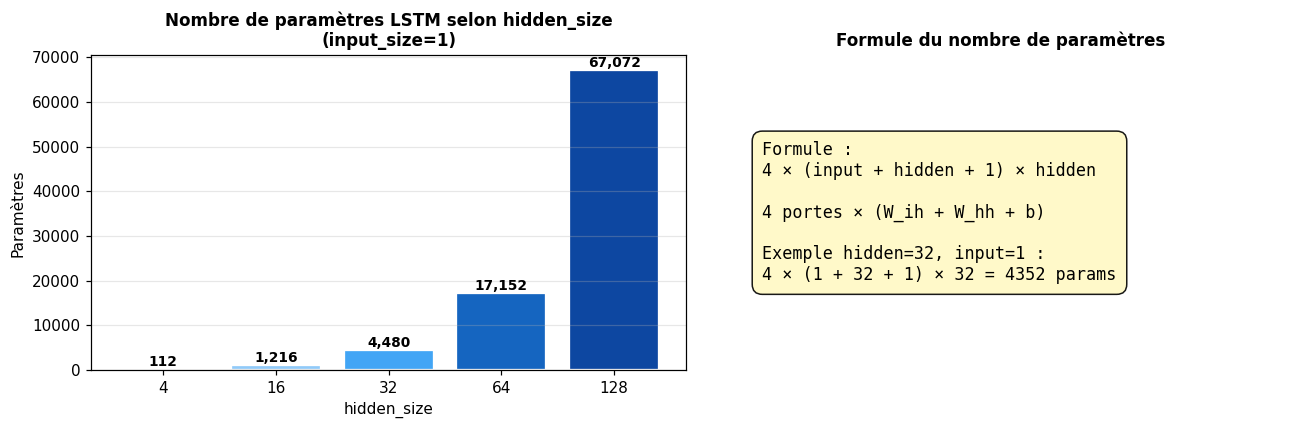

In [16]:
hidden_sizes = [4, 16, 32, 64, 128]

def compter_params(hidden):
    m = nn.LSTM(input_size=1, hidden_size=hidden, batch_first=True)
    return sum(p.numel() for p in m.parameters())

nb_params = [compter_params(h) for h in hidden_sizes]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Nombre de paramètres
couleurs_bar = ['#E3F2FD', '#90CAF9', '#42A5F5', '#1565C0', '#0D47A1']
bars = axes[0].bar([str(h) for h in hidden_sizes], nb_params,
                    color=couleurs_bar, edgecolor='white', linewidth=1.5)
for bar, n in zip(bars, nb_params):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                  f"{n:,}", ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_title("Nombre de paramètres LSTM selon hidden_size\n(input_size=1)", fontweight='bold')
axes[0].set_xlabel("hidden_size"); axes[0].set_ylabel("Paramètres")
axes[0].grid(True, alpha=0.3, axis='y')

# Formule du nombre de paramètres
info_text = (
    "Formule :\n"
    "4 × (input + hidden + 1) × hidden\n\n"
    "4 portes × (W_ih + W_hh + b)\n\n"
    "Exemple hidden=32, input=1 :\n"
    f"4 × (1 + 32 + 1) × 32 = {4 * (1 + 32 + 1) * 32} params"
)
axes[1].text(0.1, 0.5, info_text, transform=axes[1].transAxes,
              fontsize=11, verticalalignment='center',
              bbox=dict(boxstyle='round,pad=0.6', facecolor='#FFF9C4', alpha=0.9),
              fontfamily='monospace')
axes[1].axis('off')
axes[1].set_title("Formule du nombre de paramètres", fontweight='bold')

plt.tight_layout()
plt.show()